In [1]:
from pathlib import Path
import os, IPython
pwd = os.getcwd()

def validate_results(metrics_dir: str = "metrics/"):
    """
    Run validate_results.py inside the current notebook kernel so the
    confusion-matrix and ROC figures appear inline.
    """
    metrics_dir = Path(metrics_dir).expanduser().resolve()

    if not metrics_dir.exists():
        raise FileNotFoundError(f"{metrics_dir} does not exist")

    notebook = IPython.get_ipython()
    notebook.run_line_magic(
        "run",
        f"{pwd}/validate_results.py --metrics-dir {metrics_dir}"
    )


In [2]:
import tensorflow as tf, tf2onnx

model = tf.keras.models.load_model("models/keras/cnn_model.h5", compile=False)
model.summary()

sig = [tf.TensorSpec([None, 28, 28, 1], tf.float32, name="images")]  # adapt!

onnx_model, _ = tf2onnx.convert.from_keras(model,
                                           input_signature=sig,
                                           opset=18,
                                           output_path="models/onnx/cnn_model.onnx")


2025-07-30 22:13:17.887245: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-30 22:13:17.887448: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 22:13:17.889636: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 22:13:17.914164: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-30 22:13:18.355673: W tensorflow/compiler/tf2tensorrt/utils/py_uti

Model: "keras_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_3 (InputLayer)            │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0 (Conv2D)                 │ (None, 26, 26, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_0 (BatchNormalization)  │ (None, 26, 26, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_0 (Activation)         │ (None, 26, 26, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_0 (MaxPooling2D)           │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 11, 11, 24)     │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 11, 11, 24)     │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 11, 11, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 5, 5, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 42)             │        25,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_0 (BatchNormalization) │ (None, 42)             │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_act_0 (Activation)        │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 10)             │           430 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,558 (115.46 KB)

 Trainable params: 29,394 (114.82 KB)

 Non-trainable params: 164 (656.00 B)

2025-07-30 22:13:19.601609: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2025-07-30 22:13:19.601696: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2025-07-30 22:13:19.689597: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2025-07-30 22:13:19.689672: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session


In [3]:
import onnx
from onnx2pytorch import ConvertModel

# Convert ONNX model to PyTorch
pytorch_model = ConvertModel(
        onnx_model,
        experimental=True       # removes the batch-size==1 guard
)
# Save the PyTorch model
import torch
torch.save(pytorch_model.state_dict(), "models/pytorch/cnn_model.pth")
pytorch_model

/home/theodoros/Documents/AI_ON_FPGA_TARGET_SCRIPTS/.venv/lib/python3.12/site-packages/onnx2pytorch/convert/layer.py:30: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:204.)
  layer.weight.data = torch.from_numpy(numpy_helper.to_array(weight))
/home/theodoros/Documents/AI_ON_FPGA_TARGET_SCRIPTS/.venv/lib/python3.12/site-packages/onnx2pytorch/convert/model.py:147: UserWarning: Using experimental implementation that allows 'batch_size > 1'.Batchnorm layers could potentially produce false outputs.
  warnings.warn(


ConvertModel(
  (Reshape_keras_baseline_1/bn_conv_0_1/batchnorm/mul_1__6:0): Reshape(shape=[-1  1 28 28])
  (Conv_Conv__34:0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (Relu_keras_baseline_1/conv_act_0_1/Relu:0): ReLU(inplace=True)
  (MaxPool_keras_baseline_1/pool_0_1/MaxPool2d:0): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (Conv_Conv__36:0): Conv2d(16, 24, kernel_size=(3, 3), stride=(1, 1))
  (Relu_keras_baseline_1/conv_act_1_1/Relu:0): ReLU(inplace=True)
  (MaxPool_keras_baseline_1/pool_1_1/MaxPool2d:0): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (Transpose_Transpose__38:0): Transpose()
  (Shape_Shape__42:0): Shape()
  (Gather_keras_baseline_1/flatten_2_1/Shape:0): Gather()
  (Cast_keras_baseline_1/flatten_2_1/Shape__22:0): Cast(dtype=torch.int32)
  (Slice_keras_baseline_1/flatten_2_1/strided_slice:0): Slice()
  (Cast_keras_baseline_1/flatten_2_1/Reshape__33:0): Cast(dtype=torch.int64)
 

In [4]:
import torchvision 

from torchvision import transforms

# Define the transformation to convert MNIST images to tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

#load the MNIST dataset
mnist_dataset = torchvision.datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Create a DataLoader for the dataset
mnist_loader = torch.utils.data.DataLoader(mnist_dataset, batch_size=100, shuffle=False)



In [ ]:
import datetime
import torch
import numpy as np


def evaluate_model(model, mnist_loader, device="cpu",batch_size=100):
    """
    Evaluate the model on the test dataset.
    Args:
        model: The model to evaluate.
        x_test: Test input data.
        y_test: Test labels.
        device: Device to run the evaluation on (default is "cpu").
    """
    start_time = 0
    end_time = 0
    correct = []
    total = []
    batch_time = []
    model.eval()  # Set the model to evaluation mode
    model.to(device)  # Move the model to the specified device

    with torch.no_grad():  # Disable gradient calculation
        for images, labels in mnist_loader:
            images = images.to(device)
            labels = labels.to(device)
            start_time = datetime.datetime.now()
            outputs = model(images)
            end_time = datetime.datetime.now()
            _, predicted = torch.max(outputs.data, 1)
            
            correct.append((predicted == labels).sum().item())
            total.append(labels.size(0))
            batch_time.append((end_time - start_time).total_seconds())


    accuracy = sum(correct) / sum(total)
    latency = np.mean(batch_time) * 1000 / batch_size  # Convert to milliseconds per sample
    throughput = batch_size / latency  # Convert to samples per second
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Latency: {latency:.4f} ms ± {np.std(batch_time) * 1000:.4f} ms")
    print(f"Throughput: {throughput:.4f} samples/s ± {np.std(batch_time) * 1000 / batch_size:.4f} samples/sec")  

    

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
evaluate_model(pytorch_model, mnist_loader, device="cpu",batch_size=100)

/home/theodoros/Documents/AI_ON_FPGA_TARGET_SCRIPTS/.venv/lib/python3.12/site-packages/onnx2pytorch/operations/gather.py:13: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:309.)
  return data.__getitem__(selection)
/home/theodoros/Documents/AI_ON_FPGA_TARGET_SCRIPTS/.venv/lib/python3.12/site-packages/onnx2pytorch/operations/slice.py:86: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/t

Accuracy: 0.9816


TypeError: unsupported operand type(s) for /: 'list' and 'int'

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
evaluate_model(pytorch_model, mnist_loader, device=device,batch_size=100)

Accuracy: 0.9816
Latency: 0.0470 ms ± 36.1011 ms
Throughput: 2127.7818 samples/s ± 0.3610 samples/sec


HW vs GT Accuracy   : 97.73%
HW vs Golden Accuracy: 99.99%

[Latency/Throughput 1]
  Latency   : 0.4564 ms ± 0.2441  (min=0.3660, max=6.9030)
  Throughput: 2308.98 inf/s ± 343.72

[Latency/Throughput 2]
  Latency   : 0.1281 ms ± 0.0787  (min=0.1010, max=4.3270)
  Throughput: 8243.00 inf/s ± 1317.30
[Power] Estimated idle baseline ⇒ 545.34 mW (first 52 pts)

[Power Summary]
  Avg Net Power: 7.78 mW  (σ=8.67)
  Min / Max Net: 0.00 / 69.66 mW
  Total Energy (net): 31.06 mJ
  Idle Power Avg: 545.34 mW
  Avg Energy/sample: 0.0264 mJ (N=27)
  Power histogram saved → /home/theodoros/Documents/AI_ON_FPGA_TARGET_SCRIPTS/metrics/rf_analysis/power_histogram.png
Confusion matrix saved → /home/theodoros/Documents/AI_ON_FPGA_TARGET_SCRIPTS/metrics/rf_analysis/confusion_matrix.png
ROC curve saved        → /home/theodoros/Documents/AI_ON_FPGA_TARGET_SCRIPTS/metrics/rf_analysis/roc_curve.png


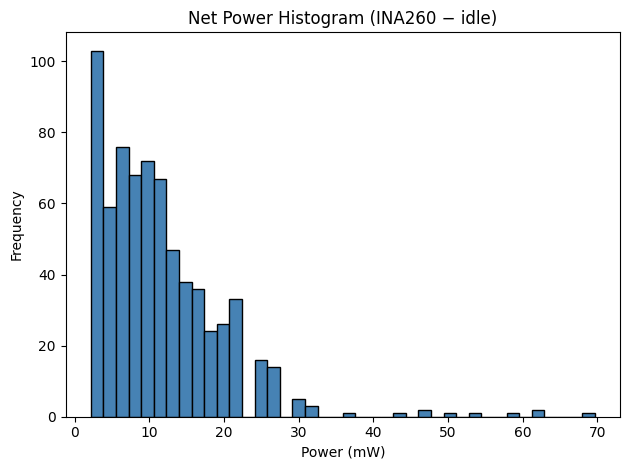

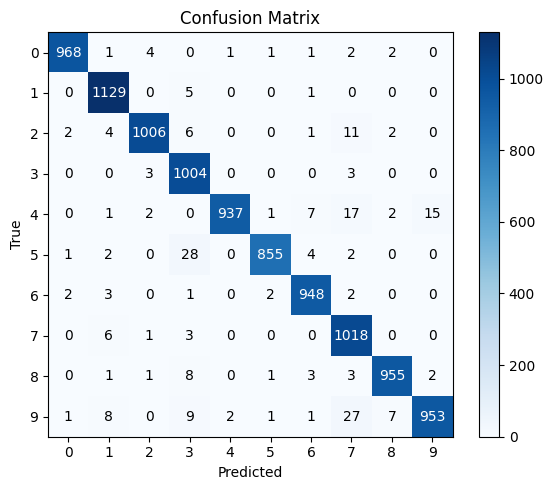

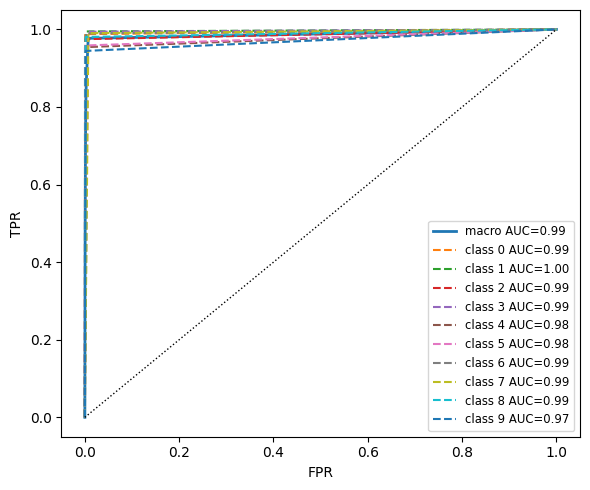

In [10]:
validate_results("metrics/rf_analysis")  # Validate results and generate figures